In [208]:
# Import Required Libraries
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

In [209]:
# Load the dataset
data = pd.read_csv('spam_ham_dataset.csv')
data.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [210]:
data.drop(columns=['Unnamed: 0'], inplace=True)

In [211]:
data.isnull().sum()

label        0
text         0
label_num    0
dtype: int64

In [212]:
data.drop_duplicates(inplace=True)

In [213]:
data.shape

(4993, 3)

In [214]:
data.head()

,label,text,label_num
0,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,spam,"Subject: photoshop , windows , office . cheap ...",1
4,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [215]:
data['label'].value_counts()

label
ham     3531
spam    1462
Name: count, dtype: int64

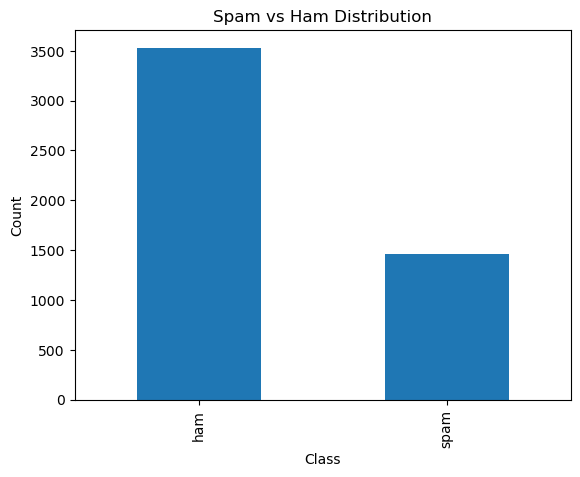

In [216]:
import matplotlib.pyplot as plt

data['label'].value_counts().plot(kind='bar')

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Spam vs Ham Distribution")

plt.show()

In [217]:
# Preprocess the text
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    if pd.isna(text):
        return ""

    # lowercase
    text = text.lower()

    # remove urls
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # remove emails
    text = re.sub(r'\S+@\S+', ' ', text)

    # remove numbers & punctuation
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # tokenize
    tokens = text.split()

    # stopwords removal + lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    return ' '.join(tokens)

data['processed_text'] = data['text'].astype(str).apply(preprocess_text)

data[['text', 'processed_text']].head()

[nltk_data] Downloading package stopwords to C:\Users\Lenovo -
[nltk_data]     LOQ\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Lenovo -
[nltk_data]     LOQ\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,text,processed_text
0,Subject: enron methanol ; meter # : 988291\r\n...,subject enron methanol meter follow note gave ...
1,"Subject: hpl nom for january 9 , 2001\r\n( see...",subject hpl nom january see attached file hpln...
2,"Subject: neon retreat\r\nho ho ho , we ' re ar...",subject neon retreat ho ho ho around wonderful...
3,"Subject: photoshop , windows , office . cheap ...",subject photoshop window office cheap main tre...
4,Subject: re : indian springs\r\nthis deal is t...,subject indian spring deal book teco pvr reven...


In [218]:
# Convert Text to Numbers using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1,2),
    min_df=2
)
X = vectorizer.fit_transform(data['processed_text'])

y = data['label_num']

In [219]:
# Split the Data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.2,random_state=42, stratify=y )

In [220]:
# Train the Classifier using SGD
from sklearn.linear_model import SGDClassifier

model = SGDClassifier(
    loss='hinge',
    alpha=1e-4,
    random_state=42
)

model.fit(X_train, y_train)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [221]:
import joblib

joblib.dump(model, "spam_model.pkl")
joblib.dump(vectorizer, "tfidf.pkl")

['tfidf.pkl']

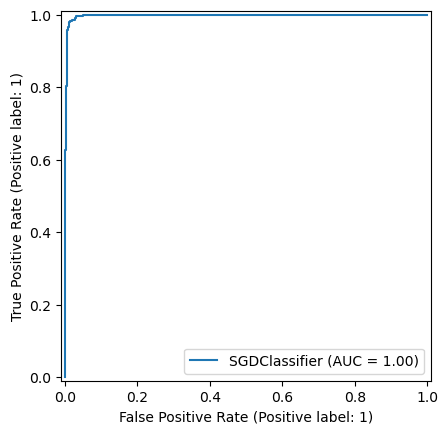

In [222]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(model, X_test, y_test)

plt.show()

In [223]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_predict = model.predict(X_test)
print("Confusion Matrix:",confusion_matrix(y_test,y_predict))
print("Accuracy:",accuracy_score(y_test,y_predict))
print(classification_report(y_test, y_predict))

Confusion Matrix: [[699   7]
 [  6 287]]
Accuracy: 0.986986986986987
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       706
           1       0.98      0.98      0.98       293

    accuracy                           0.99       999
   macro avg       0.98      0.98      0.98       999
weighted avg       0.99      0.99      0.99       999



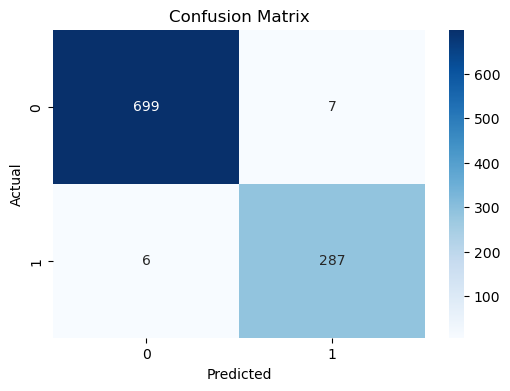

In [224]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_predict)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [225]:
# Predict New Email from User Input

new_email = input("Enter the email text: ")

# Preprocess the email
processed_email = preprocess_text(new_email)

# Convert text to numbers using TF-IDF
email_vector = vectorizer.transform([processed_email])

# Predict
prediction = model.predict(email_vector)

# Show Result
if prediction[0] == 1:
    print("This email is SPAM")
else:
    print("This email is HAM (Not Spam)")

This email is SPAM
